# Comparativa de Redes Neuronales para Verificación de Firmas
## MLP y CNN — SGD vs Adam — Con y Sin Dropout

## 1. Carga y Partición del Dataset

In [2]:
import os, random
from google.colab import drive

drive.mount('/content/drive')

ruta_dataset = '/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/DATASET/IMAGENES_DEF'

firmas_verdaderas, firmas_falsas = [], []

for archivo in os.listdir(ruta_dataset):
    if archivo.lower().endswith(('.png', '.jpg', '.jpeg')):
        partes = archivo.split('_')
        if len(partes) >= 2:
            ruta = os.path.join(ruta_dataset, archivo)
            if partes[1] == '00':
                firmas_verdaderas.append(ruta)
            else:
                firmas_falsas.append(ruta)

print(f"Total firmas verdaderas: {len(firmas_verdaderas)}")
print(f"Total firmas falsas    : {len(firmas_falsas)}")

random.seed(42)
random.shuffle(firmas_verdaderas)
random.shuffle(firmas_falsas)

train_set = firmas_verdaderas[:529]   + firmas_falsas[:529]
val_set   = firmas_verdaderas[529:642]+ firmas_falsas[529:642]
test_set  = firmas_verdaderas[642:756]+ firmas_falsas[642:756]

random.shuffle(train_set)
random.shuffle(val_set)
random.shuffle(test_set)

print(f"Entrenamiento: {len(train_set)} | Validación: {len(val_set)} | Test: {len(test_set)}")


Mounted at /content/drive
Total firmas verdaderas: 756
Total firmas falsas    : 756
Entrenamiento: 1058 | Validación: 226 | Test: 228


## 2. Funciones de Preprocesamiento

- **MLP** → imágenes redimensionadas a **64×64** (4 096 características de entrada)
- **CNN** → imágenes con padding a **320×320** (dimensión original del dataset)

In [3]:
import cv2
import numpy as np

def procesar_imagenes_reducidas(rutas):
    """Preprocesa para la MLP: padding 40px + resize 64x64 + norm. invertida.
    Salida: ndarray (N, 64, 64), dtype float32."""
    imgs = []
    for ruta in rutas:
        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_pad  = cv2.copyMakeBorder(img, 40, 40, 0, 0, cv2.BORDER_CONSTANT, value=255)
            img_red  = cv2.resize(img_pad, (64, 64), interpolation=cv2.INTER_AREA)
            img_norm = 1.0 - (img_red.astype(np.float32) / 255.0)
            imgs.append(img_norm)
    return np.array(imgs)  # (N, 64, 64)

def procesar_imagenes_cnn(rutas):
    """Preprocesa para la CNN: padding 40px (320x320) + norm. invertida.
    Salida: ndarray (N, 320, 320), dtype float32."""
    imgs = []
    for ruta in rutas:
        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_pad  = cv2.copyMakeBorder(img, 40, 40, 0, 0, cv2.BORDER_CONSTANT, value=255)
            img_norm = 1.0 - (img_pad.astype(np.float32) / 255.0)
            imgs.append(img_norm)
    return np.array(imgs)  # (N, 320, 320)

print("Funciones de preprocesamiento definidas.")


Funciones de preprocesamiento definidas.


## 3. Preparación de Datos

In [4]:
# ── Etiquetas comunes ─────────────────────────────────────────────────────────
y_train = np.array([1 if '_00_' in r else 0 for r in train_set])
y_val   = np.array([1 if '_00_' in r else 0 for r in val_set])
y_test  = np.array([1 if '_00_' in r else 0 for r in test_set])

# ── MLP: 64×64 ────────────────────────────────────────────────────────────────
print("[MLP] Procesando a 64x64...")
X_train_mlp = procesar_imagenes_reducidas(train_set)
X_val_mlp   = procesar_imagenes_reducidas(val_set)
X_test_mlp  = procesar_imagenes_reducidas(test_set)
print(f"  X_train_mlp: {X_train_mlp.shape}  X_val_mlp: {X_val_mlp.shape}")

# ── CNN: 320×320 ──────────────────────────────────────────────────────────────
print("[CNN] Procesando a 320x320...")
X_train_cnn = procesar_imagenes_cnn(train_set)
X_val_cnn   = procesar_imagenes_cnn(val_set)
X_test_cnn  = procesar_imagenes_cnn(test_set)
print(f"  X_train_cnn: {X_train_cnn.shape}  X_val_cnn: {X_val_cnn.shape}")


[MLP] Procesando a 64x64...
  X_train_mlp: (1058, 64, 64)  X_val_mlp: (226, 64, 64)
[CNN] Procesando a 320x320...
  X_train_cnn: (1058, 320, 320)  X_val_cnn: (226, 320, 320)


## 4. Definición de Arquitecturas
### 4.1 MLP (entrada 64×64 = 4 096)

La clase `FirmaMLP` acepta ahora el parámetro `dropout_p`:
- `dropout_p=0.0` → **sin dropout**
- `dropout_p=0.5` → **con dropout** (50 % en capa 1, 30 % en capa 2)

In [5]:
import torch
import torch.nn as nn

class FirmaMLP(nn.Module):
    """MLP para verificación de firmas. Entrada: (N, 64, 64).
    dropout_p=0.0  → variante SIN dropout.
    dropout_p > 0  → variante CON dropout (0.5 y 0.3 en capas 1-2)."""
    def __init__(self, dropout_p: float = 0.5):
        super().__init__()
        capas = [
            nn.Flatten(),
            nn.Linear(4096, 512), nn.BatchNorm1d(512), nn.ReLU(),
        ]
        if dropout_p > 0.0:
            capas.append(nn.Dropout(dropout_p))
        capas += [
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(),
        ]
        if dropout_p > 0.0:
            capas.append(nn.Dropout(dropout_p * 0.6))  # 0.3 si dropout_p=0.5
        capas += [
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 1)
        ]
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        return self.red(x)

print("FirmaMLP definida  —  entrada (N,64,64) salida (N,1)")


FirmaMLP definida  —  entrada (N,64,64) salida (N,1)


### 4.2 CNN (entrada 320×320) — variante con y sin Dropout

In [6]:
class FirmaCNN(nn.Module):
    """CNN ligera para verificación de firmas.
    Entrada: (N, 1, 320, 320).
    dropout_p=0.0  → variante SIN dropout.
    dropout_p=0.5  → variante CON dropout."""
    def __init__(self, dropout_p: float = 0.5):
        super().__init__()
        self.bloque1 = nn.Sequential(
            nn.Conv2d(1,  16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2,2)
        )  # → (N,16,160,160)
        self.bloque2 = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2,2)
        )  # → (N,16,80,80)
        self.bloque3 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2,2)
        )  # → (N,32,40,40)
        self.bloque4 = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2,2)
        )  # → (N,32,20,20)  →  flatten: 32*20*20 = 12800
        capas = [nn.Linear(12800, 256), nn.ReLU()]
        if dropout_p > 0.0:
            capas.append(nn.Dropout(dropout_p))
        capas.append(nn.Linear(256, 1))
        self.clasificador = nn.Sequential(*capas)

    def forward(self, x):
        x = self.bloque4(self.bloque3(self.bloque2(self.bloque1(x))))
        return self.clasificador(torch.flatten(x, 1))

# Verificación rápida de dimensiones
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
with torch.no_grad():
    _y = FirmaMLP().to(device)(torch.zeros(2, 64, 64).to(device))
    print(f"FirmaMLP  salida: {_y.shape}  OK")
    _y = FirmaCNN(0.5).to(device)(torch.zeros(2, 1, 320, 320).to(device))
    print(f"FirmaCNN  salida: {_y.shape}  OK")


Dispositivo: cpu
FirmaMLP  salida: torch.Size([2, 1])  OK
FirmaCNN  salida: torch.Size([2, 1])  OK


## 5. Función de Evaluación Biométrica

In [7]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_curve)
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def evaluar_modelo(y_true, y_pred_probs, nombres_imagenes=None, tau=0.5):
    """Métricas estándar y biométricas.
    tau : umbral de decisión — ajusta para mover el punto de operación."""
    y_true       = np.array(y_true).flatten()
    y_pred_probs = np.array(y_pred_probs).flatten()
    y_pred       = (y_pred_probs >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    except Exception:
        eer = fpr[np.nanargmin(np.abs((1 - tpr) - fpr))]

    print("=" * 50)
    print(f"  EVALUACIÓN  —  τ = {tau}")
    print("=" * 50)
    print(f"  VP={tp}  VN={tn}  FP={fp}  FN={fn}")
    print(f"  Accuracy : {accuracy:.4f}   F1-Score : {f1:.4f}")
    print(f"  Precision: {precision:.4f}   Recall   : {recall:.4f}")
    print(f"  FAR      : {far:.4f}   FRR      : {frr:.4f}   EER: {eer:.4f}")
    print("=" * 50)

    fps_imgs = fns_imgs = np.array([])
    if nombres_imagenes is not None:
        nombres_imagenes = np.array(nombres_imagenes)
        fps_imgs = nombres_imagenes[(y_true == 0) & (y_pred == 1)]
        fns_imgs = nombres_imagenes[(y_true == 1) & (y_pred == 0)]
        if len(fps_imgs): print(f"  FP (muestra): {fps_imgs[:3]}")
        if len(fns_imgs): print(f"  FN (muestra): {fns_imgs[:3]}")
    return fps_imgs, fns_imgs

print("evaluar_modelo definida.")


evaluar_modelo definida.


## 6. Función Genérica de Entrenamiento

In [9]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

def construir_loaders_mlp(batch_size=64):
    tX_tr = torch.tensor(X_train_mlp, dtype=torch.float32)
    ty_tr = torch.tensor(y_train,     dtype=torch.float32).unsqueeze(1)
    tX_vl = torch.tensor(X_val_mlp,   dtype=torch.float32)
    ty_vl = torch.tensor(y_val,       dtype=torch.float32).unsqueeze(1)
    return (DataLoader(TensorDataset(tX_tr,ty_tr), batch_size, shuffle=True),
            DataLoader(TensorDataset(tX_vl,ty_vl), batch_size, shuffle=False))

def construir_loaders_cnn(batch_size=16):
    tX_tr = torch.tensor(X_train_cnn, dtype=torch.float32).unsqueeze(1)
    ty_tr = torch.tensor(y_train,     dtype=torch.float32).unsqueeze(1)
    tX_vl = torch.tensor(X_val_cnn,   dtype=torch.float32).unsqueeze(1)
    ty_vl = torch.tensor(y_val,       dtype=torch.float32).unsqueeze(1)
    return (DataLoader(TensorDataset(tX_tr,ty_tr), batch_size, shuffle=True),
            DataLoader(TensorDataset(tX_vl,ty_vl), batch_size, shuffle=False))

def entrenar(modelo, optimizador, loader_tr, loader_vl,
             epocas=100, nombre="modelo", ruta_guardado=".", lambda_l2=1e-4):
    """Entrena el modelo y guarda los pesos al finalizar.
    Devuelve (hist_train, hist_val) — listas de pérdida media por época.

    lambda_l2 : coeficiente de regularización L2 aplicado explícitamente
                sobre la función de pérdida (suma de normas al cuadrado
                de todos los parámetros del modelo).
                Usar 0.0 para desactivarla.
    """
    criterio = nn.BCEWithLogitsLoss()
    hist_tr, hist_vl = [], []
    print(f"\n{'─'*55}")
    print(f"  EXPERIMENTO: {nombre}  ({epocas} épocas)  λ_L2={lambda_l2}")
    print(f"{'─'*55}")

    for ep in range(epocas):
        modelo.train()
        acum = 0.0
        for Xb, yb in loader_tr:
            Xb, yb = Xb.to(device), yb.to(device)
            # ── Pérdida BCE + penalización L2 explícita ───────────────────
            loss = criterio(modelo(Xb), yb)
            if lambda_l2 > 0.0:
                l2_reg = sum(p.pow(2).sum() for p in modelo.parameters())
                loss = loss + lambda_l2 * l2_reg
            # ─────────────────────────────────────────────────────────────
            optimizador.zero_grad(); loss.backward(); optimizador.step()
            acum += loss.item() * Xb.size(0)
        hist_tr.append(acum / len(loader_tr.dataset))

        modelo.eval()
        acum = 0.0
        with torch.no_grad():
            for Xb, yb in loader_vl:
                Xb, yb = Xb.to(device), yb.to(device)
                loss_vl = criterio(modelo(Xb), yb)
                if lambda_l2 > 0.0:
                    l2_reg = sum(p.pow(2).sum() for p in modelo.parameters())
                    loss_vl = loss_vl + lambda_l2 * l2_reg
                acum += loss_vl.item() * Xb.size(0)
        hist_vl.append(acum / len(loader_vl.dataset))

        if (ep+1) % max(1, epocas//10) == 0 or ep == 0:
            print(f"  Época {ep+1:3d}/{epocas}  Train: {hist_tr[-1]:.4f}  Val: {hist_vl[-1]:.4f}")

    ruta_pt = os.path.join(ruta_guardado, f"{nombre}.pt")
    torch.save(modelo.state_dict(), ruta_pt)
    print(f"  Modelo guardado → {ruta_pt}")
    return hist_tr, hist_vl

print("Funciones de entrenamiento definidas.")


Funciones de entrenamiento definidas.


## 7. Configuración Global de Experimentos
Ajusta estos parámetros antes de ejecutar los entrenamientos.

In [10]:
# ─── PARÁMETROS AJUSTABLES ────────────────────────────────────────────────────
EPOCAS_MLP   = 100    # Épocas para la MLP
EPOCAS_CNN   = 20     # Épocas para la CNN

LR_SGD_MLP   = 1e-2   # Learning rate SGD — MLP
LR_ADAM_MLP  = 1e-4   # Learning rate Adam — MLP
LR_SGD_CNN   = 1e-2   # Learning rate SGD — CNN
LR_ADAM_CNN  = 1e-4   # Learning rate Adam — CNN

LAMBDA_L2    = 1e-4   # Coeficiente de regularización L2

# Carpeta de Drive donde se guardarán los archivos .pt y las gráficas
RUTA_GUARDADO = '/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS'
os.makedirs(RUTA_GUARDADO, exist_ok=True)
print(f"Modelos se guardarán en: {RUTA_GUARDADO}")

historiales = {}  # Acumula los historiales de pérdida de todos los experimentos


Modelos se guardarán en: /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS


## 8. Experimentos

In [11]:
loader_tr_mlp, loader_vl_mlp = construir_loaders_mlp(batch_size=64)
loader_tr_cnn, loader_vl_cnn = construir_loaders_cnn(batch_size=16)

### 8.1 MLP + SGD (sin Dropout)

In [ ]:
mlp_sgd_nd      = FirmaMLP(dropout_p=0.0).to(device)
opt_mlp_sgd_nd  = optim.SGD(mlp_sgd_nd.parameters(), lr=LR_SGD_MLP)

tr, vl = entrenar(mlp_sgd_nd, opt_mlp_sgd_nd, loader_tr_mlp, loader_vl_mlp,
                  epocas=EPOCAS_MLP, nombre="MLP_SGD_SinDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["MLP_SGD_SinDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: MLP_SGD_SinDropout  (100 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/100  Train: 0.7536  Val: 0.7735
  Época  10/100  Train: 0.2492  Val: 0.3272
  Época  20/100  Train: 0.1231  Val: 0.2368
  Época  30/100  Train: 0.1031  Val: 0.2222
  Época  40/100  Train: 0.0958  Val: 0.2179
  Época  50/100  Train: 0.0924  Val: 0.2165
  Época  60/100  Train: 0.0918  Val: 0.2160
  Época  70/100  Train: 0.0903  Val: 0.2159
  Época  80/100  Train: 0.0897  Val: 0.2157
  Época  90/100  Train: 0.0893  Val: 0.2157
  Época 100/100  Train: 0.0887  Val: 0.2126
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/MLP_SGD_SinDropout.pt


### 8.2 MLP + SGD (con Dropout)

In [ ]:
mlp_sgd_d      = FirmaMLP(dropout_p=0.5).to(device)
opt_mlp_sgd_d  = optim.SGD(mlp_sgd_d.parameters(), lr=LR_SGD_MLP)

tr, vl = entrenar(mlp_sgd_d, opt_mlp_sgd_d, loader_tr_mlp, loader_vl_mlp,
                  epocas=EPOCAS_MLP, nombre="MLP_SGD_ConDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["MLP_SGD_ConDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: MLP_SGD_ConDropout  (100 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/100  Train: 0.7723  Val: 0.7768
  Época  10/100  Train: 0.4110  Val: 0.4085
  Época  20/100  Train: 0.1863  Val: 0.2754
  Época  30/100  Train: 0.1278  Val: 0.2310
  Época  40/100  Train: 0.1085  Val: 0.2205
  Época  50/100  Train: 0.0991  Val: 0.2116
  Época  60/100  Train: 0.0965  Val: 0.2112
  Época  70/100  Train: 0.0945  Val: 0.2114
  Época  80/100  Train: 0.0926  Val: 0.2119
  Época  90/100  Train: 0.0919  Val: 0.2096
  Época 100/100  Train: 0.0907  Val: 0.2119
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/MLP_SGD_ConDropout.pt


### 8.3 MLP + Adam (sin Dropout)

In [ ]:
mlp_adam_nd      = FirmaMLP(dropout_p=0.0).to(device)
opt_mlp_adam_nd  = optim.Adam(mlp_adam_nd.parameters(), lr=LR_ADAM_MLP)

tr, vl = entrenar(mlp_adam_nd, opt_mlp_adam_nd, loader_tr_mlp, loader_vl_mlp,
                  epocas=EPOCAS_MLP, nombre="MLP_Adam_SinDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["MLP_Adam_SinDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: MLP_Adam_SinDropout  (100 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/100  Train: 0.6750  Val: 0.7238
  Época  10/100  Train: 0.2040  Val: 0.2796
  Época  20/100  Train: 0.1061  Val: 0.2003
  Época  30/100  Train: 0.0872  Val: 0.2004
  Época  40/100  Train: 0.0804  Val: 0.1745
  Época  50/100  Train: 0.0753  Val: 0.1734
  Época  60/100  Train: 0.0716  Val: 0.1794
  Época  70/100  Train: 0.0689  Val: 0.1662
  Época  80/100  Train: 0.0661  Val: 0.1654
  Época  90/100  Train: 0.0635  Val: 0.1641
  Época 100/100  Train: 0.0610  Val: 0.1621
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/MLP_Adam_SinDropout.pt


### 8.4 MLP + Adam (con Dropout)

In [ ]:
mlp_adam_d      = FirmaMLP(dropout_p=0.5).to(device)
opt_mlp_adam_d  = optim.Adam(mlp_adam_d.parameters(), lr=LR_ADAM_MLP)

tr, vl = entrenar(mlp_adam_d, opt_mlp_adam_d, loader_tr_mlp, loader_vl_mlp,
                  epocas=EPOCAS_MLP, nombre="MLP_Adam_ConDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["MLP_Adam_ConDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: MLP_Adam_ConDropout  (100 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/100  Train: 0.7249  Val: 0.7513
  Época  10/100  Train: 0.2597  Val: 0.2936
  Época  20/100  Train: 0.1200  Val: 0.2232
  Época  30/100  Train: 0.0948  Val: 0.1955
  Época  40/100  Train: 0.0841  Val: 0.1903
  Época  50/100  Train: 0.0801  Val: 0.2067
  Época  60/100  Train: 0.0758  Val: 0.2113
  Época  70/100  Train: 0.0732  Val: 0.1928
  Época  80/100  Train: 0.0703  Val: 0.1823
  Época  90/100  Train: 0.0679  Val: 0.2116
  Época 100/100  Train: 0.0655  Val: 0.1929
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/MLP_Adam_ConDropout.pt


### 8.5 CNN + SGD (sin Dropout)

In [ ]:
cnn_sgd_nd     = FirmaCNN(dropout_p=0.0).to(device)
opt_cnn_sgd_nd = optim.SGD(cnn_sgd_nd.parameters(), lr=LR_SGD_CNN)

tr, vl = entrenar(cnn_sgd_nd, opt_cnn_sgd_nd, loader_tr_cnn, loader_vl_cnn,
                  epocas=EPOCAS_CNN, nombre="CNN_SGD_SinDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["CNN_SGD_SinDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: CNN_SGD_SinDropout  (20 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/20  Train: 0.3932  Val: 0.2150
  Época   2/20  Train: 0.1821  Val: 0.1202
  Época   4/20  Train: 0.0842  Val: 0.1009
  Época   6/20  Train: 0.0377  Val: 0.0612
  Época   8/20  Train: 0.0278  Val: 0.0592
  Época  10/20  Train: 0.0257  Val: 0.0739
  Época  12/20  Train: 0.0248  Val: 0.0605
  Época  14/20  Train: 0.0238  Val: 0.0647
  Época  16/20  Train: 0.0236  Val: 0.0674
  Época  18/20  Train: 0.0231  Val: 0.0534
  Época  20/20  Train: 0.0228  Val: 0.0545
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/CNN_SGD_SinDropout.pt


### 8.6 CNN + SGD (con Dropout)

In [ ]:
cnn_sgd_d     = FirmaCNN(dropout_p=0.5).to(device)
opt_cnn_sgd_d = optim.SGD(cnn_sgd_d.parameters(), lr=LR_SGD_CNN)

tr, vl = entrenar(cnn_sgd_d, opt_cnn_sgd_d, loader_tr_cnn, loader_vl_cnn,
                  epocas=EPOCAS_CNN, nombre="CNN_SGD_ConDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["CNN_SGD_ConDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: CNN_SGD_ConDropout  (20 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/20  Train: 0.4024  Val: 0.1837
  Época   2/20  Train: 0.2155  Val: 0.1338
  Época   4/20  Train: 0.1099  Val: 0.0987
  Época   6/20  Train: 0.0752  Val: 0.1045
  Época   8/20  Train: 0.0468  Val: 4.0720
  Época  10/20  Train: 0.0485  Val: 0.0681
  Época  12/20  Train: 0.0327  Val: 0.0923
  Época  14/20  Train: 0.0310  Val: 0.0755
  Época  16/20  Train: 0.0317  Val: 0.0875
  Época  18/20  Train: 0.0251  Val: 0.0796
  Época  20/20  Train: 0.0253  Val: 0.0537
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/CNN_SGD_ConDropout.pt


### 8.7 CNN + Adam (sin Dropout)

In [ ]:
cnn_adam_nd     = FirmaCNN(dropout_p=0.0).to(device)
opt_cnn_adam_nd = optim.Adam(cnn_adam_nd.parameters(), lr=LR_ADAM_CNN)

tr, vl = entrenar(cnn_adam_nd, opt_cnn_adam_nd, loader_tr_cnn, loader_vl_cnn,
                  epocas=EPOCAS_CNN, nombre="CNN_Adam_SinDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["CNN_Adam_SinDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: CNN_Adam_SinDropout  (20 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/20  Train: 0.2633  Val: 0.1833
  Época   2/20  Train: 0.1332  Val: 0.1274
  Época   4/20  Train: 0.0438  Val: 0.1005
  Época   6/20  Train: 0.0291  Val: 0.0934
  Época   8/20  Train: 0.0258  Val: 0.0965
  Época  10/20  Train: 0.0215  Val: 0.0924
  Época  12/20  Train: 0.0205  Val: 0.0892
  Época  14/20  Train: 0.0200  Val: 0.0960
  Época  16/20  Train: 0.0194  Val: 0.0886
  Época  18/20  Train: 0.0190  Val: 0.0867
  Época  20/20  Train: 0.0187  Val: 0.0855
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/CNN_Adam_SinDropout.pt


### 8.8 CNN + Adam (con Dropout)

In [ ]:
cnn_adam_d     = FirmaCNN(dropout_p=0.5).to(device)
opt_cnn_adam_d = optim.Adam(cnn_adam_d.parameters(), lr=LR_ADAM_CNN)

tr, vl = entrenar(cnn_adam_d, opt_cnn_adam_d, loader_tr_cnn, loader_vl_cnn,
                  epocas=EPOCAS_CNN, nombre="CNN_Adam_ConDropout",
                  ruta_guardado=RUTA_GUARDADO, lambda_l2=LAMBDA_L2)
historiales["CNN_Adam_ConDropout"] = {"train": tr, "val": vl}



───────────────────────────────────────────────────────
  EXPERIMENTO: CNN_Adam_ConDropout  (20 épocas)  λ_L2=0.0001
───────────────────────────────────────────────────────
  Época   1/20  Train: 0.3173  Val: 0.1742
  Época   2/20  Train: 0.1646  Val: 0.1168
  Época   4/20  Train: 0.0921  Val: 0.0824
  Época   6/20  Train: 0.0527  Val: 0.0947
  Época   8/20  Train: 0.0450  Val: 0.0717
  Época  10/20  Train: 0.0294  Val: 0.0669
  Época  12/20  Train: 0.0265  Val: 0.1078
  Época  14/20  Train: 0.0222  Val: 0.0674
  Época  16/20  Train: 0.0234  Val: 0.0621
  Época  18/20  Train: 0.0208  Val: 0.0608
  Época  20/20  Train: 0.0196  Val: 0.0544
  Modelo guardado → /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/CNN_Adam_ConDropout.pt


## 9. Gráfica Comparativa de Pérdidas

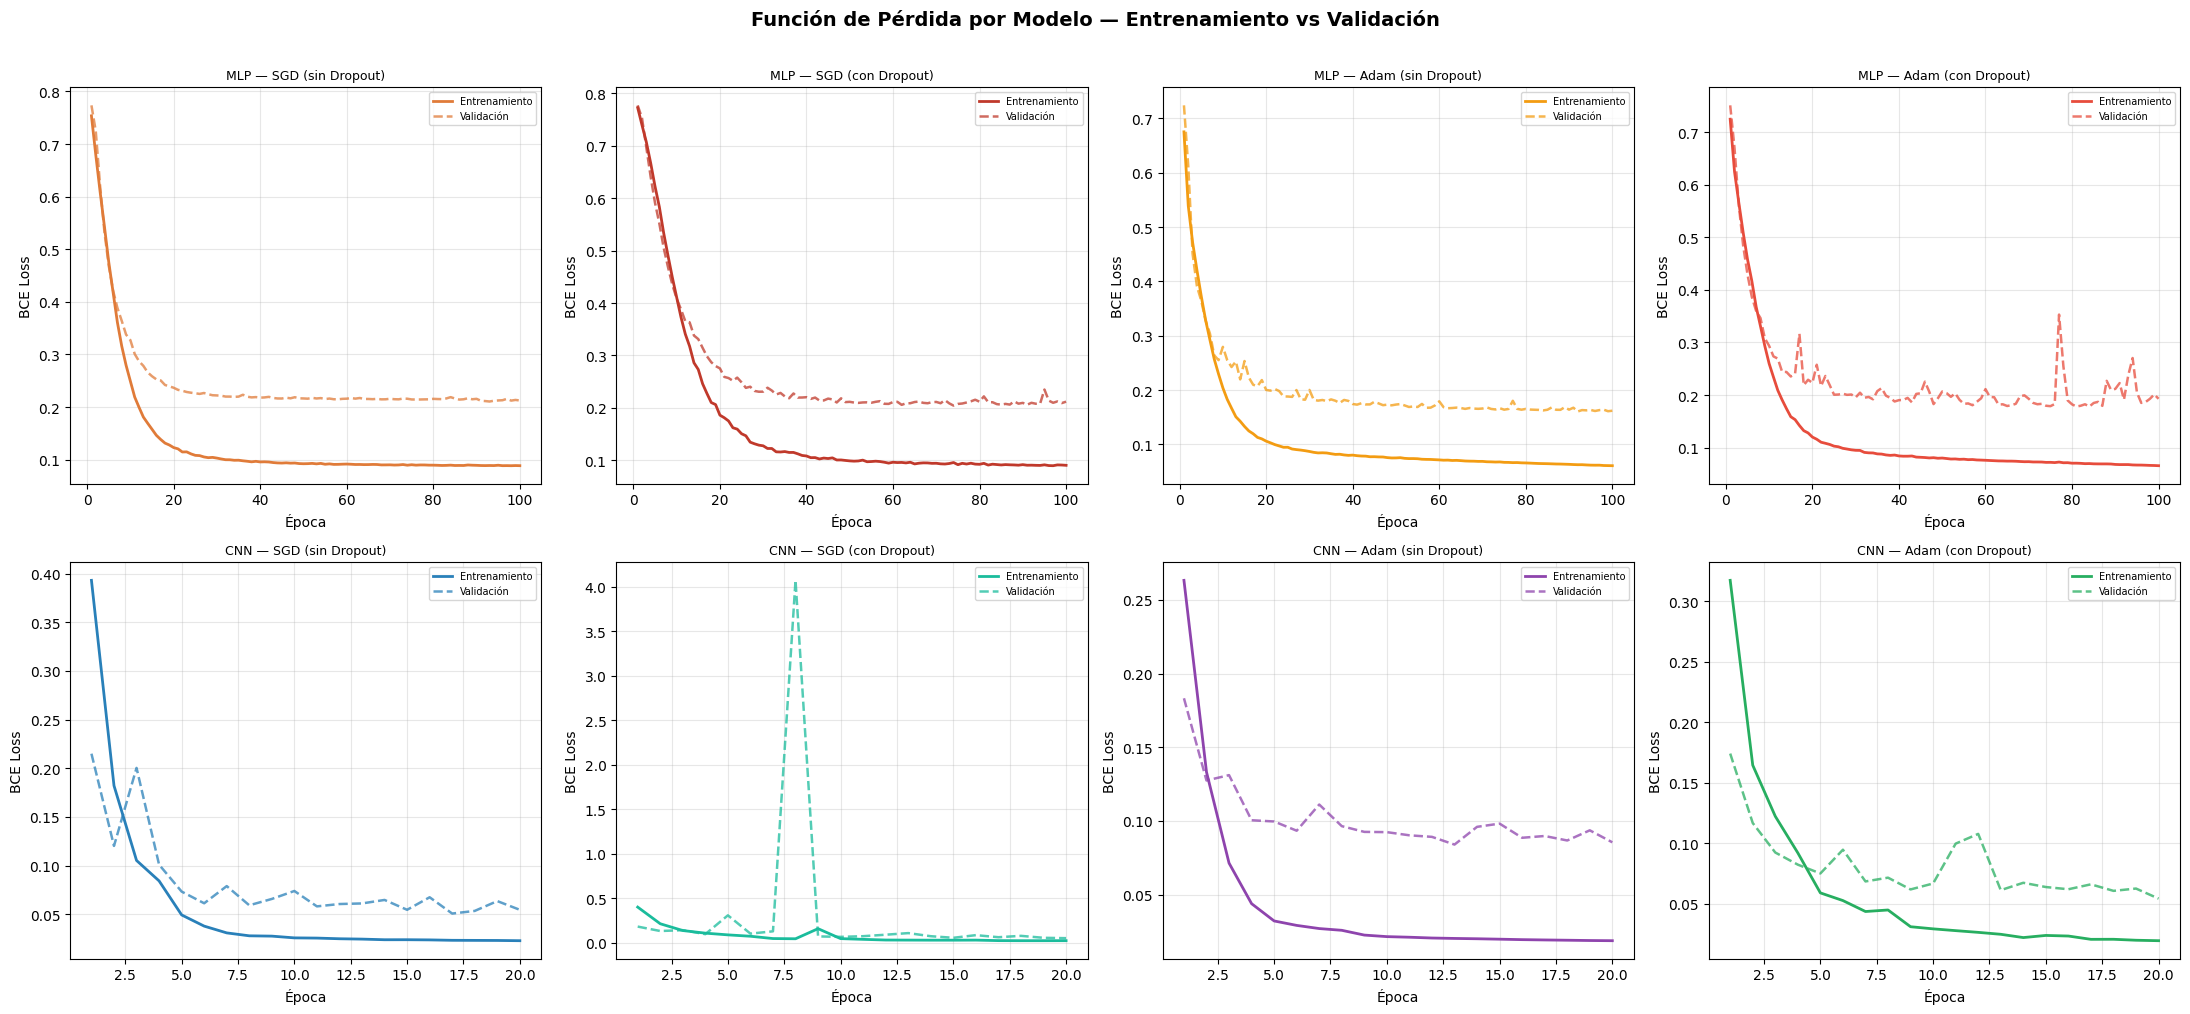

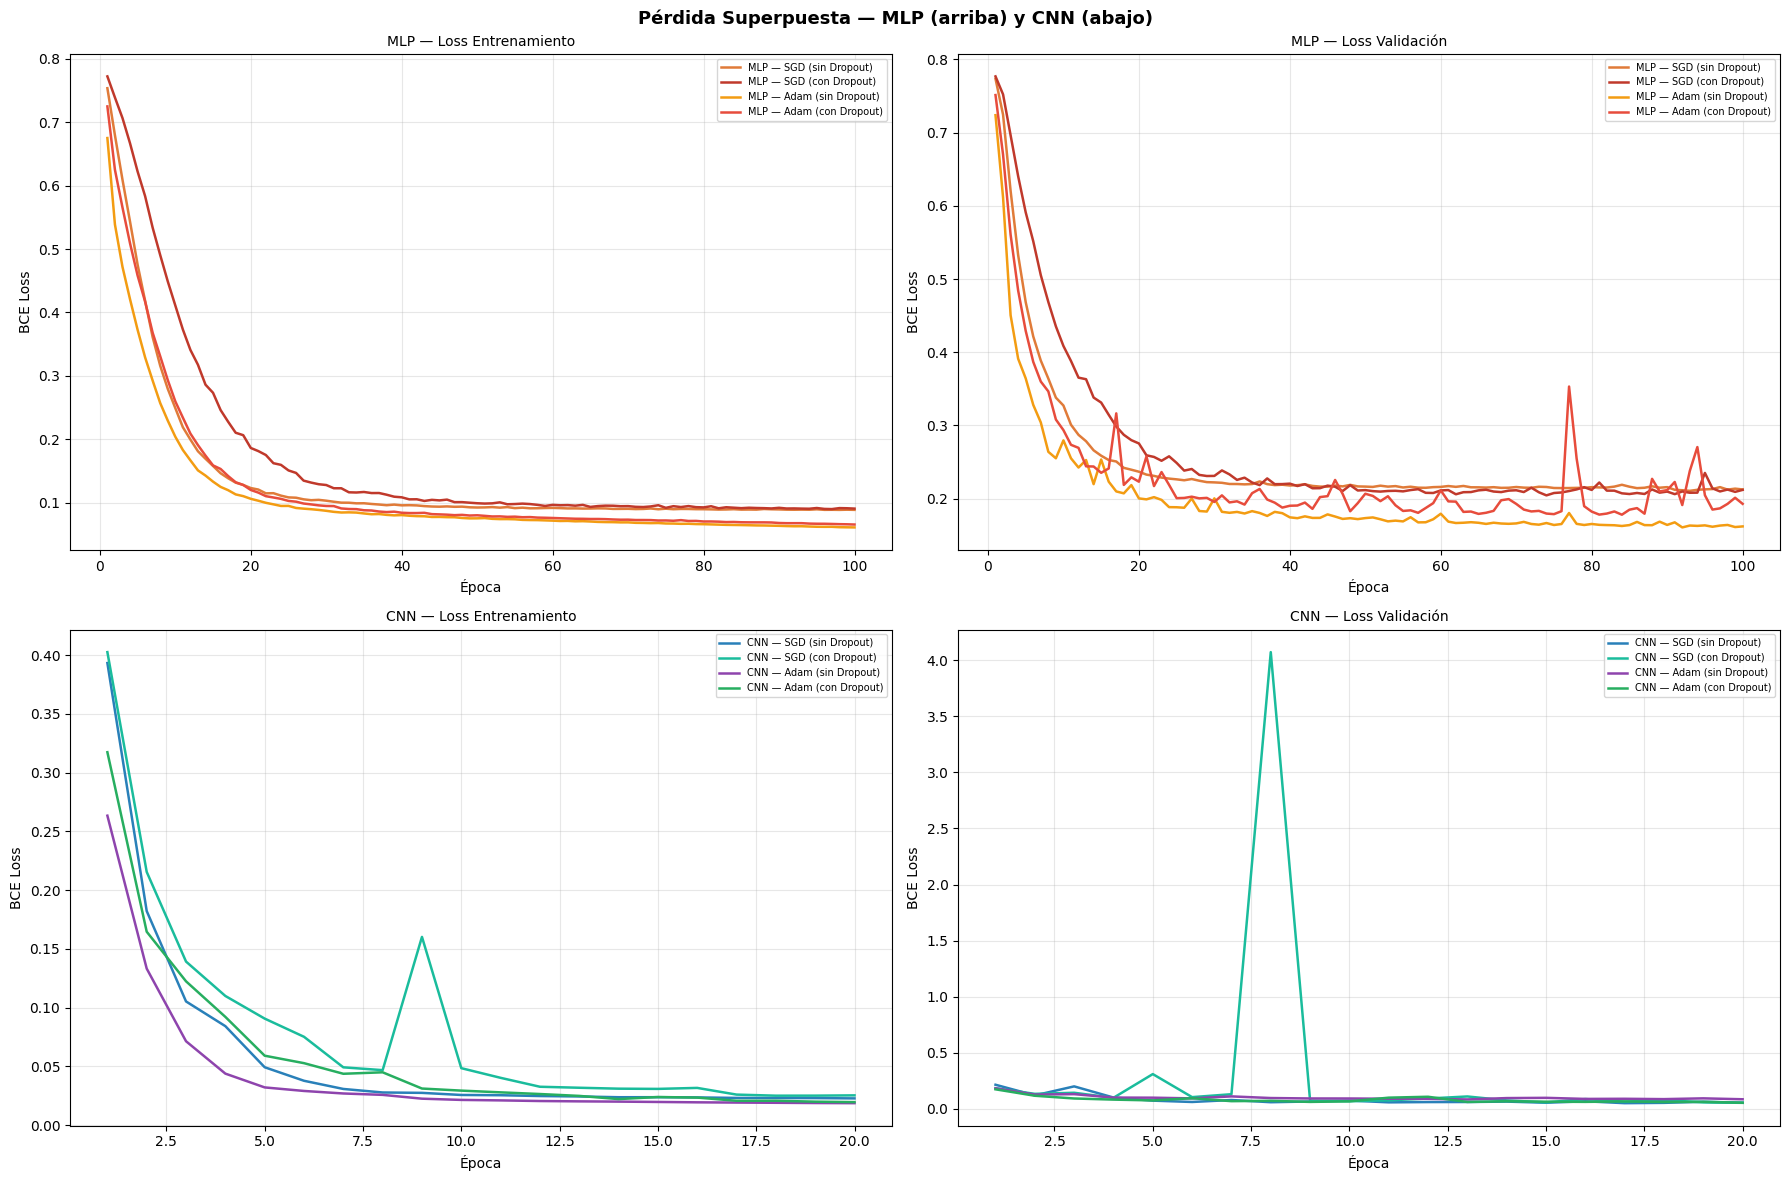

Gráficas guardadas en Drive.


In [ ]:
import matplotlib.pyplot as plt

COLORES = {
    "MLP_SGD_SinDropout":  "#e07b39",
    "MLP_SGD_ConDropout":  "#c0392b",
    "MLP_Adam_SinDropout": "#f39c12",
    "MLP_Adam_ConDropout": "#e74c3c",
    "CNN_SGD_SinDropout":  "#2980b9",
    "CNN_SGD_ConDropout":  "#1abc9c",
    "CNN_Adam_SinDropout": "#8e44ad",
    "CNN_Adam_ConDropout": "#27ae60",
}
ETIQUETAS = {
    "MLP_SGD_SinDropout":  "MLP — SGD (sin Dropout)",
    "MLP_SGD_ConDropout":  "MLP — SGD (con Dropout)",
    "MLP_Adam_SinDropout": "MLP — Adam (sin Dropout)",
    "MLP_Adam_ConDropout": "MLP — Adam (con Dropout)",
    "CNN_SGD_SinDropout":  "CNN — SGD (sin Dropout)",
    "CNN_SGD_ConDropout":  "CNN — SGD (con Dropout)",
    "CNN_Adam_SinDropout": "CNN — Adam (sin Dropout)",
    "CNN_Adam_ConDropout": "CNN — Adam (con Dropout)",
}

# ── Figura 1: subplots individuales (2 filas x 4 columnas) ──────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Función de Pérdida por Modelo — Entrenamiento vs Validación",
             fontsize=14, fontweight="bold", y=1.01)

for ax, nombre in zip(axes.flatten(), COLORES.keys()):
    if nombre not in historiales:
        ax.set_visible(False); continue
    col = COLORES[nombre]
    tr  = historiales[nombre]["train"]
    vl  = historiales[nombre]["val"]
    eps = range(1, len(tr)+1)
    ax.plot(eps, tr, color=col, lw=2.0, label="Entrenamiento")
    ax.plot(eps, vl, color=col, lw=1.8, ls="--", alpha=0.75, label="Validación")
    ax.set_title(ETIQUETAS[nombre], fontsize=9)
    ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GUARDADO, "comparativa_subplots.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Figura 2: curvas superpuestas — MLP vs CNN por separado ─────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
fig2.suptitle("Pérdida Superpuesta — MLP (arriba) y CNN (abajo)", fontsize=13, fontweight="bold")

mlp_names = [n for n in historiales if n.startswith("MLP")]
cnn_names = [n for n in historiales if n.startswith("CNN")]

for ax, nombres, titulo in zip(
    [axes2[0,0], axes2[0,1], axes2[1,0], axes2[1,1]],
    [mlp_names, mlp_names, cnn_names, cnn_names],
    ["MLP — Loss Entrenamiento", "MLP — Loss Validación",
     "CNN — Loss Entrenamiento", "CNN — Loss Validación"]):
    es_val = "Validación" in titulo
    for nombre in nombres:
        h   = historiales[nombre]
        col = COLORES[nombre]
        eps = range(1, len(h["train"])+1)
        datos = h["val"] if es_val else h["train"]
        ax.plot(eps, datos, color=col, lw=1.8, label=ETIQUETAS[nombre])
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Época"); ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GUARDADO, "comparativa_global.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráficas guardadas en Drive.")


## 10. Tabla Resumen de Pérdida Final

In [ ]:
print(f"{'Modelo':<30} {'Train final':>12} {'Val final':>12}")
print("─" * 58)
for n, h in historiales.items():
    print(f"{n:<30} {h['train'][-1]:>12.4f} {h['val'][-1]:>12.4f}")


Modelo                          Train final    Val final
──────────────────────────────────────────────────────────
MLP_SGD_SinDropout                   0.0887       0.2126
MLP_SGD_ConDropout                   0.0907       0.2119
MLP_Adam_SinDropout                  0.0610       0.1621
MLP_Adam_ConDropout                  0.0655       0.1929
CNN_SGD_SinDropout                   0.0228       0.0545
CNN_SGD_ConDropout                   0.0253       0.0537
CNN_Adam_SinDropout                  0.0187       0.0855
CNN_Adam_ConDropout                  0.0196       0.0544


## 11. Validación con Tau Ajustable

Modifica `NOMBRE_MODELO`, `TAU` y `CONJUNTO` y re-ejecuta la celda para evaluar cualquier modelo guardado con el umbral que quieras.

In [14]:
# ─── PARÁMETROS AJUSTABLES ────────────────────────────────────────────────────
NOMBRE_MODELO = "CNN_SGD_SinDropout"  # Opciones:
                                       # MLP_SGD_SinDropout  | MLP_SGD_ConDropout
                                       # MLP_Adam_SinDropout | MLP_Adam_ConDropout
                                       # CNN_SGD_SinDropout  | CNN_SGD_ConDropout
                                       # CNN_Adam_SinDropout | CNN_Adam_ConDropout
TAU      = 0.8      # Umbral de decision tau en (0,1)
CONJUNTO = "test"    # "val" para validacion  /  "test" para evaluacion ciega
# ──────────────────────────────────────────────────────────────────────────────

es_mlp  = NOMBRE_MODELO.startswith("MLP")
es_drop = "ConDropout" in NOMBRE_MODELO

# Seleccion de arquitectura y datos
if es_mlp:
    modelo_v = FirmaMLP(dropout_p=0.5 if es_drop else 0.0).to(device)
    X_ev     = X_val_mlp  if CONJUNTO == "val" else X_test_mlp
    y_ev     = y_val      if CONJUNTO == "val" else y_test
    rutas_ev = val_set    if CONJUNTO == "val" else test_set
    loader_v = DataLoader(TensorDataset(
        torch.tensor(X_ev, dtype=torch.float32),
        torch.tensor(y_ev, dtype=torch.float32).unsqueeze(1)),
        batch_size=64, shuffle=False)
else:
    modelo_v = FirmaCNN(dropout_p=0.5 if es_drop else 0.0).to(device)
    X_ev     = X_val_cnn  if CONJUNTO == "val" else X_test_cnn
    y_ev     = y_val      if CONJUNTO == "val" else y_test
    rutas_ev = val_set    if CONJUNTO == "val" else test_set
    loader_v = DataLoader(TensorDataset(
        torch.tensor(X_ev, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_ev, dtype=torch.float32).unsqueeze(1)),
        batch_size=16, shuffle=False)

# Cargar pesos
ruta_pt = os.path.join(RUTA_GUARDADO, f"{NOMBRE_MODELO}.pt")
modelo_v.load_state_dict(torch.load(ruta_pt, map_location=device))
modelo_v.eval()
print(f"Modelo cargado: {ruta_pt}")
print(f"Conjunto: {CONJUNTO.upper()}  |  tau = {TAU}")

# Inferencia
probs_v, etqs_v = [], []
with torch.no_grad():
    for Xb, yb in loader_v:
        p = torch.sigmoid(modelo_v(Xb.to(device))).cpu().numpy()
        probs_v.extend(p); etqs_v.extend(yb.numpy())

fps, fns = evaluar_modelo(etqs_v, probs_v, nombres_imagenes=rutas_ev, tau=TAU)


Modelo cargado: /content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/CNN_SGD_SinDropout.pt
Conjunto: TEST  |  tau = 0.8
  EVALUACIÓN  —  τ = 0.8
  VP=110  VN=114  FP=0  FN=4
  Accuracy : 0.9825   F1-Score : 0.9821
  Precision: 1.0000   Recall   : 0.9649
  FAR      : 0.0000   FRR      : 0.0351   EER: 0.0088
  FN (muestra): ['/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/DATASET/IMAGENES_DEF/003_00_02_08.png'
 '/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/DATASET/IMAGENES_DEF/001_00_01_01.png'
 '/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/DATASET/IMAGENES_DEF/001_00_01_06.png']


## 12. Evaluación Comparativa de Todos los Modelos

Evalúa todos los modelos entrenados sobre el **conjunto de test**, con τ = 0.5,
y acumula las métricas en un diccionario para generar la tabla comparativa.
Ajusta `TAU_GLOBAL` si quieres un umbral de operación distinto.


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

TAU_GLOBAL = 0.5  # Umbral global para la evaluación comparativa

TODOS_MODELOS = [
    ("MLP_SGD_SinDropout",  "mlp", 0.0),
    ("MLP_SGD_ConDropout",  "mlp", 0.5),
    ("MLP_Adam_SinDropout", "mlp", 0.0),
    ("MLP_Adam_ConDropout", "mlp", 0.5),
    ("CNN_SGD_SinDropout",  "cnn", 0.0),
    ("CNN_SGD_ConDropout",  "cnn", 0.5),
    ("CNN_Adam_SinDropout", "cnn", 0.0),
    ("CNN_Adam_ConDropout", "cnn", 0.5),
]

resultados = {}

for nombre, tipo, dp in TODOS_MODELOS:
    ruta_pt = os.path.join(RUTA_GUARDADO, f"{nombre}.pt")
    if not os.path.exists(ruta_pt):
        print(f"  [!] No encontrado: {ruta_pt}  — saltando")
        continue

    if tipo == "mlp":
        modelo_e = FirmaMLP(dropout_p=dp).to(device)
        loader_e = DataLoader(TensorDataset(
            torch.tensor(X_test_mlp, dtype=torch.float32),
            torch.tensor(y_test,     dtype=torch.float32).unsqueeze(1)),
            batch_size=64, shuffle=False)
    else:
        modelo_e = FirmaCNN(dropout_p=dp).to(device)
        loader_e = DataLoader(TensorDataset(
            torch.tensor(X_test_cnn, dtype=torch.float32).unsqueeze(1),
            torch.tensor(y_test,     dtype=torch.float32).unsqueeze(1)),
            batch_size=16, shuffle=False)

    modelo_e.load_state_dict(torch.load(ruta_pt, map_location=device))
    modelo_e.eval()

    probs_e, etqs_e = [], []
    with torch.no_grad():
        for Xb, yb in loader_e:
            p = torch.sigmoid(modelo_e(Xb.to(device))).cpu().numpy()
            probs_e.extend(p); etqs_e.extend(yb.numpy())

    y_true_e = np.array(etqs_e).flatten()
    y_prob_e = np.array(probs_e).flatten()
    y_pred_e = (y_prob_e >= TAU_GLOBAL).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_e, y_pred_e).ravel()
    acc  = accuracy_score(y_true_e, y_pred_e)
    prec = precision_score(y_true_e, y_pred_e, zero_division=0)
    rec  = recall_score(y_true_e, y_pred_e, zero_division=0)
    f1   = f1_score(y_true_e, y_pred_e, zero_division=0)
    far  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    frr  = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    fpr_c, tpr_c, _ = roc_curve(y_true_e, y_prob_e)
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr_c, tpr_c)(x), 0., 1.)
    except Exception:
        eer = fpr_c[np.nanargmin(np.abs((1 - tpr_c) - fpr_c))]

    resultados[nombre] = {
        "VP": tp, "VN": tn, "FP": fp, "FN": fn,
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1": f1, "FAR": far, "FRR": frr, "EER": eer,
    }
    print(f"  ✓ {nombre}")

print(f"\nEvaluación completada para {len(resultados)} modelos.")


  ✓ MLP_SGD_SinDropout
  ✓ MLP_SGD_ConDropout
  ✓ MLP_Adam_SinDropout
  ✓ MLP_Adam_ConDropout
  ✓ CNN_SGD_SinDropout
  ✓ CNN_SGD_ConDropout
  ✓ CNN_Adam_SinDropout
  ✓ CNN_Adam_ConDropout

Evaluación completada para 8 modelos.


## 13. Tabla Comparativa Final

La celda muestra:
1. **Matrices de confusión** de cada modelo en formato texto compacto.
2. **Tabla de parámetros biométricos** (Accuracy, Precision, Recall, F1, FAR, FRR, EER)
   con todos los modelos en filas, ordenados de menor a mayor EER.


In [ ]:
# ── 1. Matrices de confusión compactas ───────────────────────────────────────
print("=" * 65)
print("  MATRICES DE CONFUSIÓN — Conjunto de Test  (τ = {:.2f})".format(TAU_GLOBAL))
print("=" * 65)
col_w = 28
for nombre, m in resultados.items():
    tp, tn, fp, fn = m["VP"], m["VN"], m["FP"], m["FN"]
    etiqueta = ETIQUETAS.get(nombre, nombre)
    print(f"\n  {etiqueta}")
    print(f"  {'─' * 34}")
    print(f"  {'':<18} Pred Verdadera  Pred Falsa")
    print(f"  {'Real Verdadera':<18}   VP = {tp:>4}        FN = {fn:>4}")
    print(f"  {'Real Falsa':<18}   FP = {fp:>4}        VN = {tn:>4}")

# ── 2. Tabla de métricas biométricas ─────────────────────────────────────────
filas = []
for nombre, m in resultados.items():
    filas.append({
        "Modelo": ETIQUETAS.get(nombre, nombre),
        "VP": m["VP"], "VN": m["VN"], "FP": m["FP"], "FN": m["FN"],
        "Accuracy":  round(m["Accuracy"],  4),
        "Precision": round(m["Precision"], 4),
        "Recall":    round(m["Recall"],    4),
        "F1-Score":  round(m["F1"],        4),
        "FAR":       round(m["FAR"],       4),
        "FRR":       round(m["FRR"],       4),
        "EER":       round(m["EER"],       4),
    })

df_res = pd.DataFrame(filas).sort_values("EER")

print("\n")
print("=" * 110)
print("  COMPARATIVA DE PARÁMETROS BIOMÉTRICOS — Ordenado por EER (↑ mejor)")
print("=" * 110)
print(df_res.to_string(index=False))
print("=" * 110)

# ── 3. Guardar tabla como CSV ─────────────────────────────────────────────────
ruta_csv = os.path.join(RUTA_GUARDADO, "comparativa_biometrica.csv")
df_res.to_csv(ruta_csv, index=False)
print(f"\nTabla guardada en: {ruta_csv}")

# ── 4. Gráfico de barras comparativo ─────────────────────────────────────────
metricas_plot = ["Accuracy", "F1-Score", "FAR", "FRR", "EER"]
x = range(len(df_res))
modelos_cortos = [m.replace("MLP — ", "MLP\n").replace("CNN — ", "CNN\n") for m in df_res["Modelo"]]

fig3, axes3 = plt.subplots(1, len(metricas_plot), figsize=(22, 5))
fig3.suptitle("Comparativa de Métricas por Modelo — Test Set", fontsize=13, fontweight="bold")

bar_colors = [COLORES.get(n, "#888888") for n in resultados.keys()]
sorted_names = df_res["Modelo"].tolist()
bar_colors_sorted = [COLORES.get(
    next((k for k, v in ETIQUETAS.items() if v == mn), ""), "#888888")
    for mn in sorted_names]

for ax3, metrica in zip(axes3, metricas_plot):
    valores = df_res[metrica].tolist()
    bars = ax3.bar(x, valores, color=bar_colors_sorted, alpha=0.85, edgecolor="white")
    ax3.set_xticks(list(x))
    ax3.set_xticklabels(modelos_cortos, fontsize=6, rotation=30, ha="right")
    ax3.set_title(metrica, fontsize=10)
    ax3.set_ylim(0, 1.05)
    ax3.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, valores):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_GUARDADO, "comparativa_barras.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico de barras guardado.")


In [17]:
import torch
from torch.utils.mobile_optimizer import optimize_for_mobile

# 1. Instanciar la MISMA arquitectura que usaste en el entrenamiento
# Al ser el modelo SIN Dropout, establecemos la probabilidad a 0.0
modelo_para_movil = FirmaCNN(dropout_p=0.0)

# 2. Cargar los pesos (.pt) en la estructura
# Ruta apuntando al modelo SGD sin Dropout
ruta_tu_mejor_modelo = '/content/drive/MyDrive/CUARTO/TFG VICTOR MARCOS/MODELOS/CNN_SGD_SinDropout.pt'
modelo_para_movil.load_state_dict(torch.load(ruta_tu_mejor_modelo, map_location=torch.device('cpu')))

# 3. Poner en modo evaluación (siempre recomendado, aunque la probabilidad de Dropout sea 0)
modelo_para_movil.eval()

# 4. Crear el tensor de ejemplo con la forma exacta que vimos en tu notebook:
# [Tamaño de lote (1), Canales (1 para gris), Alto (320), Ancho (320)]
example_input = torch.rand(1, 1, 320, 320)

# 5. Trazar el modelo (TorchScript)
traced_script_module = torch.jit.trace(modelo_para_movil, example_input)

# 6. Optimizar específicamente para el intérprete móvil
optimized_traced_model = optimize_for_mobile(traced_script_module)

# 7. Guardar el archivo definitivo con un nombre representativo
nombre_salida = "firma_cnn_sgd_sindropout_optimizado.ptl"
optimized_traced_model._save_for_lite_interpreter(nombre_salida)

print(f"¡Listo! Descarga el archivo '{nombre_salida}' a tu ordenador.")

¡Listo! Descarga el archivo 'firma_cnn_sgd_sindropout_optimizado.ptl' a tu ordenador.


/tmp/ipykernel_1894/3830538145.py:28: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_traced_model._save_for_lite_interpreter(nombre_salida)
